# Normalizing ACE SWEPAM Variables

Before mapping spacecraft measurements to sound, this notebook compares several ways to transform physical ACE SWEPAM variables into normalized values. The goal is not to make the data sound musical yet. The goal is to understand which transformations preserve scientifically meaningful structure, which ones exaggerate noise, and which ones are risky because of invalid data gaps.

Variables explored here:
- `Np`: proton number density
- `Vp`: solar wind speed
- `Tpr`: proton temperature


In [1]:
from pathlib import Path

import cdflib
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = Path("../data/ac_h0_swe_20240709_v11.cdf")
cdf = cdflib.CDF(DATA_PATH)
times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

VARIABLES = {
    "Np": "Proton number density",
    "Vp": "Solar wind speed",
    "Tpr": "Proton temperature",
}

print(f"Loaded: {DATA_PATH.name}")
print(f"Samples: {len(times)}")


Loaded: ac_h0_swe_20240709_v11.cdf
Samples: 1350


## Load and Clean Variables

CDF attributes define fill values and valid physical ranges. The cleaning function below keeps the raw time axis, creates a boolean valid-sample mask, and also returns a compact valid-only array for statistics and normalization experiments.

Keeping the mask matters because later sonification should know where the spacecraft record has missing or invalid intervals instead of silently closing those gaps.


In [2]:
def clean_variable(cdf_file, variable_name, time_values):
    """Load one CDF variable and identify samples that are scientifically valid."""
    values = np.asarray(cdf_file.varget(variable_name), dtype=float)
    attrs = cdf_file.varattsget(variable_name)

    mask = np.isfinite(values)

    fill_value = attrs.get("FILLVAL")
    if fill_value is not None:
        mask &= values != fill_value

    valid_min = attrs.get("VALIDMIN")
    if valid_min is not None:
        mask &= values >= valid_min

    valid_max = attrs.get("VALIDMAX")
    if valid_max is not None:
        mask &= values <= valid_max

    return {
        "name": variable_name,
        "label": attrs.get("FIELDNAM", variable_name),
        "description": attrs.get("CATDESC", ""),
        "units": attrs.get("UNITS", ""),
        "values": values,
        "times": time_values,
        "mask": mask,
        "valid_values": values[mask],
        "attrs": attrs,
    }


def apply_mask_as_nan(values, mask):
    """Preserve the original time axis while marking invalid samples as NaN."""
    cleaned = np.asarray(values, dtype=float).copy()
    cleaned[~mask] = np.nan
    return cleaned


data = {
    variable: clean_variable(cdf, variable, times)
    for variable in VARIABLES
}

for variable, record in data.items():
    record["nan_values"] = apply_mask_as_nan(record["values"], record["mask"])


In [3]:
for variable, record in data.items():
    total = len(record["values"])
    valid = int(np.sum(record["mask"]))
    invalid = total - valid
    invalid_percent = 100 * invalid / total

    print("-" * 40)
    print(variable, "-", VARIABLES[variable])
    print("Units:", record["units"])
    print("Original samples:", total)
    print("Valid samples:", valid)
    print(f"Invalid samples: {invalid} ({invalid_percent:.2f}%)")


----------------------------------------
Np - Proton number density
Units: #/cc
Original samples: 1350
Valid samples: 482
Invalid samples: 868 (64.30%)
----------------------------------------
Vp - Solar wind speed
Units: km/s
Original samples: 1350
Valid samples: 1257
Invalid samples: 93 (6.89%)
----------------------------------------
Tpr - Proton temperature
Units: Kelvin
Original samples: 1350
Valid samples: 1212
Invalid samples: 138 (10.22%)


## Normalization Methods

These methods each answer a slightly different question:

- Min-max normalization maps the observed valid range to 0-1, but can be overly controlled by extremes.
- Robust percentile normalization maps the central 1st-99th percentile range to 0-1 and clips outliers.
- Z-score normalization shows deviation from the mean in standard-deviation units, useful for analysis but not bounded to 0-1.
- Log min-max normalization can help with right-skewed positive variables such as proton temperature.


In [4]:
def min_max_normalize(values):
    values = np.asarray(values, dtype=float)
    data_min = np.nanmin(values)
    data_max = np.nanmax(values)

    if data_max == data_min:
        return np.zeros_like(values, dtype=float)

    return (values - data_min) / (data_max - data_min)


def robust_normalize(values, lower_percentile=1, upper_percentile=99):
    values = np.asarray(values, dtype=float)
    lower, upper = np.nanpercentile(values, [lower_percentile, upper_percentile])

    if upper == lower:
        return np.zeros_like(values, dtype=float)

    normalized = (values - lower) / (upper - lower)
    return np.clip(normalized, 0, 1)


def z_score_normalize(values):
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    std = np.nanstd(values)

    if std == 0:
        return np.zeros_like(values, dtype=float)

    return (values - mean) / std


def log_min_max_normalize(values):
    values = np.asarray(values, dtype=float)
    positive_values = np.where(values > 0, values, np.nan)
    return min_max_normalize(np.log10(positive_values))


In [5]:
normalization_methods = {
    "min_max": min_max_normalize,
    "robust_1_99": robust_normalize,
    "z_score": z_score_normalize,
    "log_min_max": log_min_max_normalize,
}

for record in data.values():
    record["normalized"] = {
        method_name: method(record["nan_values"])
        for method_name, method in normalization_methods.items()
    }


## Compare Time-Series Behavior

The plots below preserve the original time axis and leave invalid intervals as gaps. This makes it easier to see whether normalization keeps the structure of the measurement or makes invalid/missing regions misleading.


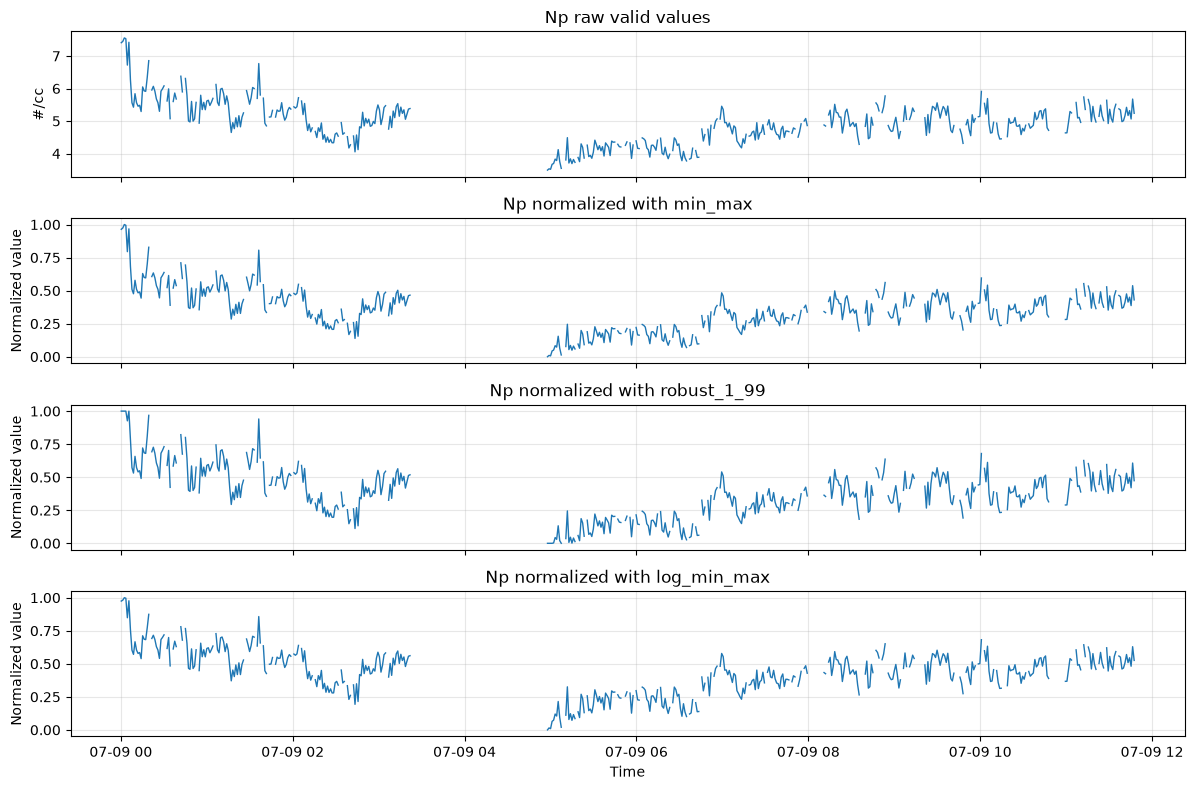

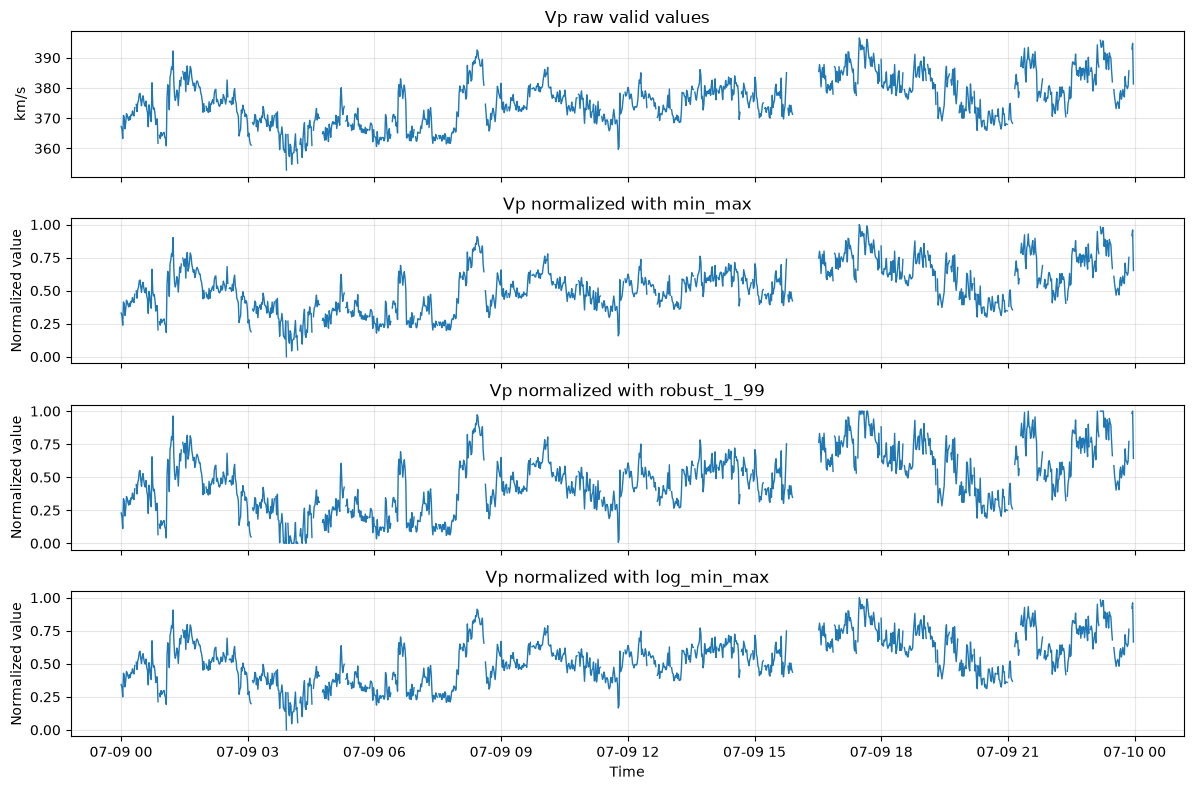

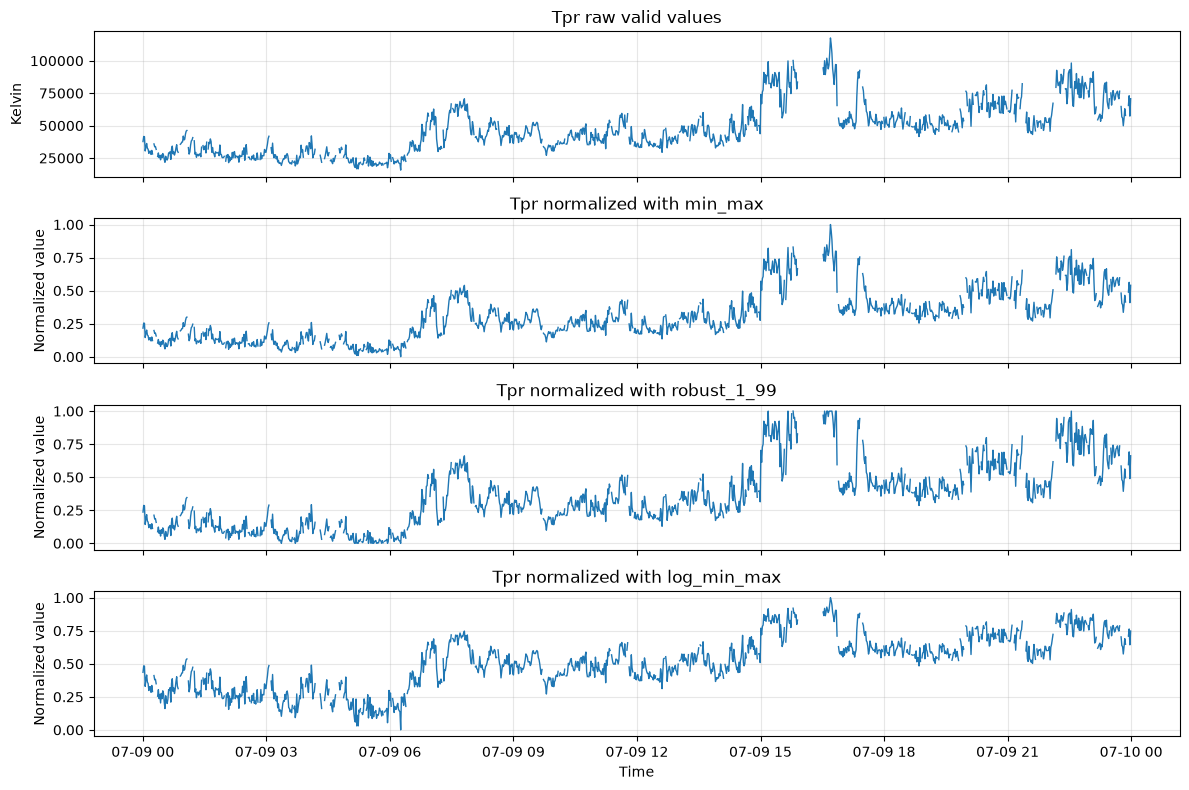

In [6]:
def plot_raw_and_normalized(record, methods=("min_max", "robust_1_99", "log_min_max")):
    fig, axes = plt.subplots(len(methods) + 1, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(record["times"], record["nan_values"], linewidth=1)
    axes[0].set_title(f"{record['name']} raw valid values")
    axes[0].set_ylabel(record["units"])
    axes[0].grid(alpha=0.3)

    for axis, method_name in zip(axes[1:], methods):
        axis.plot(record["times"], record["normalized"][method_name], linewidth=1)
        axis.set_title(f"{record['name']} normalized with {method_name}")
        axis.set_ylabel("Normalized value")
        axis.grid(alpha=0.3)

    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()


for variable in VARIABLES:
    plot_raw_and_normalized(data[variable])


## Compare Normalized Distributions

Histograms help reveal whether a normalization method spreads the variable across a useful range or compresses most samples into a narrow band. This is important for later sonification planning because compressed values may become hard to perceive, while over-expanded values may exaggerate small fluctuations.


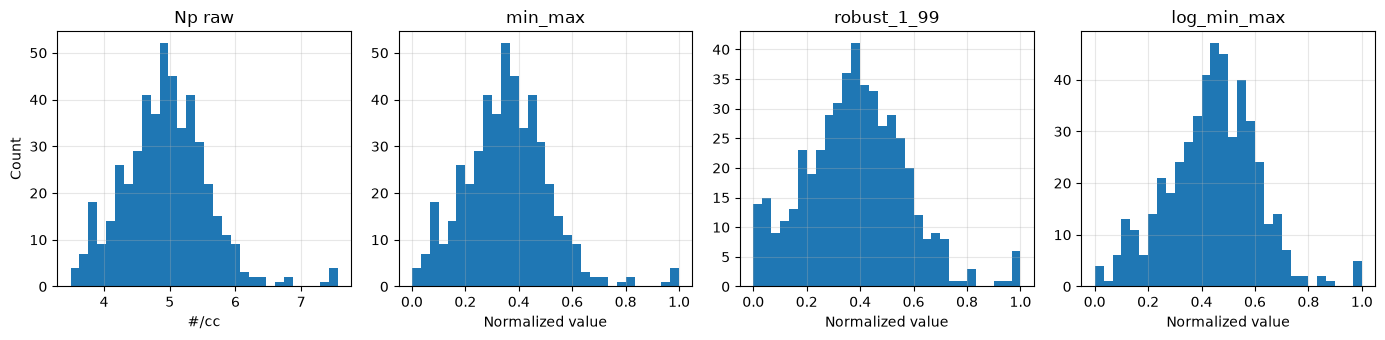

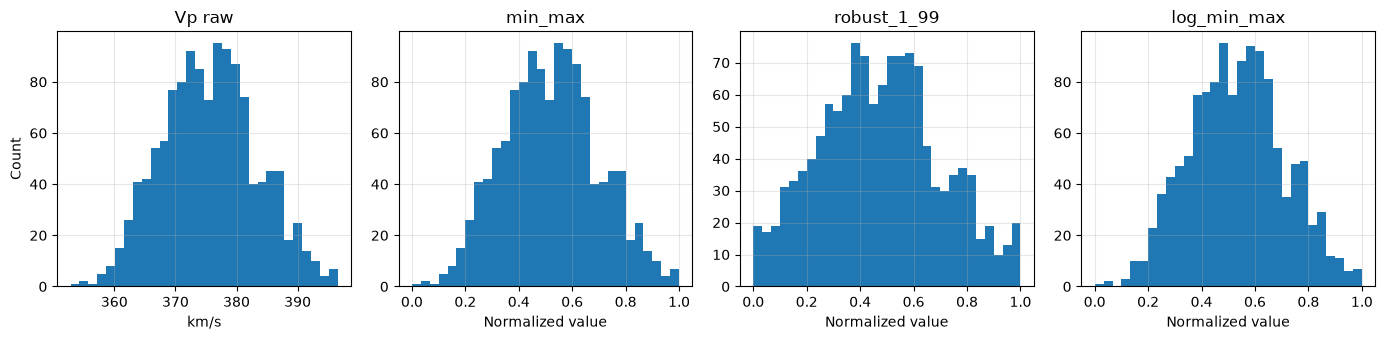

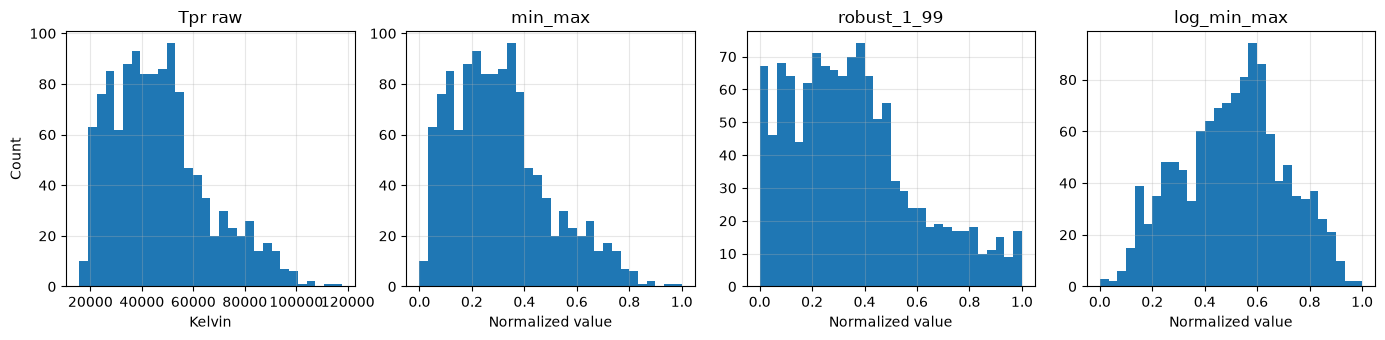

In [7]:
def plot_normalized_histograms(record, methods=("min_max", "robust_1_99", "log_min_max")):
    fig, axes = plt.subplots(1, len(methods) + 1, figsize=(14, 3.5))

    axes[0].hist(record["valid_values"], bins=30)
    axes[0].set_title(f"{record['name']} raw")
    axes[0].set_xlabel(record["units"])
    axes[0].set_ylabel("Count")
    axes[0].grid(alpha=0.3)

    for axis, method_name in zip(axes[1:], methods):
        normalized_values = record["normalized"][method_name][record["mask"]]
        axis.hist(normalized_values[np.isfinite(normalized_values)], bins=30)
        axis.set_title(method_name)
        axis.set_xlabel("Normalized value")
        axis.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


for variable in VARIABLES:
    plot_normalized_histograms(data[variable])


## Common Valid Samples

The variables do not all have the same valid samples. For direct comparison between `Np`, `Vp`, and `Tpr`, use only timestamps where all three variables are valid. This avoids comparing measurements from different parts of the day.


In [8]:
common_mask = np.ones(len(times), dtype=bool)
for record in data.values():
    common_mask &= record["mask"]

print("Total samples:", len(times))
print("Samples where Np, Vp, and Tpr are all valid:", int(np.sum(common_mask)))
print(f"Common valid coverage: {100 * np.mean(common_mask):.2f}%")


Total samples: 1350
Samples where Np, Vp, and Tpr are all valid: 472
Common valid coverage: 34.96%


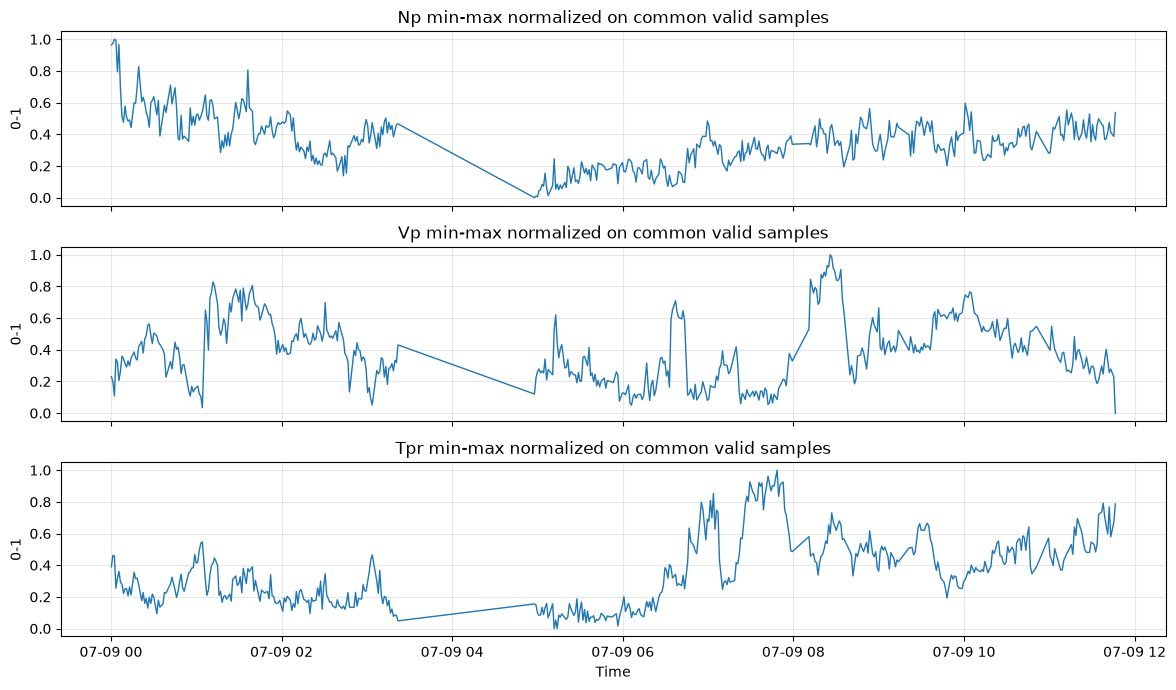

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

for axis, variable in zip(axes, VARIABLES):
    record = data[variable]
    normalized = min_max_normalize(record["values"][common_mask])
    axis.plot(times[common_mask], normalized, linewidth=1)
    axis.set_title(f"{variable} min-max normalized on common valid samples")
    axis.set_ylabel("0-1")
    axis.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


## First-Pass Normalization Decisions

| Variable | Best first candidate | Scientific reason | Main risk |
|---|---|---|---|
| `Np` | Robust percentile or min-max after gap handling | Density has a compact valid range, but valid intervals are sparse. | Many invalid samples mean sonification could imply continuity where none exists. |
| `Vp` | Min-max or z-score for analysis | Solar wind speed is physically important but varies over a narrow range in this file. | Normalization may exaggerate small fluctuations if interpreted without context. |
| `Tpr` | Log min-max or robust percentile | Proton temperature has the broadest dynamic range and a right-skewed distribution. | Linear min-max may let high-temperature values dominate the scale. |

## Notebook Conclusion

For the next exploratory step, `Tpr` is the strongest candidate for testing nonlinear normalization because it has meaningful variability and a skewed distribution. `Vp` can be normalized to make small changes visible, but interpretations should mention that the raw physical range is narrow. `Np` should not be sonified as a continuous stream until invalid intervals are handled explicitly.
